In [19]:
%pip install -q mne mne-features EntropyHub PyWavelets networkx imbalanced-learn torch

! pip install pyriemann

In [20]:
import numpy as np
import pandas as pd
import mne
from scipy.io import loadmat
from pathlib import Path

"""
Unified ErrP loader for:
- BNCI .mat files (original notebook format)
- EDF recordings with trigger/stim channels
- CSV recordings with EEG columns + trigger column
- DSI text exports (handled like CSV when they contain tabular data)

Outputs:
  X: (num_samples, num_channels, num_timesteps)
  y: (num_samples,), where 1 = ErrP, 0 = non-ErrP
"""

# --- configurable epoch window (seconds) ---
PRE_S = 0.2
POST_S = 0.8

# --- Trigger maps for PsychoPy games (outcome triggers only) ---
TRIGGER_MAPS = {
    "fruit": {
        "non_errp": {1, 2},          # correct_left, correct_right
        "errp": {3, 4, 5, 6, 7, 8, 9, 10},
        "ignore": {11, 12, 13, 14},  # cue/block/session markers
    },
    "racing": {
        "non_errp": {1, 2},          # correct_left, correct_right
        "errp": {3, 4, 5, 6, 7},
        "ignore": {8, 9, 10, 11},    # cues/block/session markers
    },
    # Trigger map for psychopy/errpGamePlain.py
    # 1 = non-error, 2/3/4 = error variants
    "errp_plain": {
        "non_errp": {1},
        "errp": {2, 3, 4},
        "ignore": set(),
    },
    # Compatibility map for BNCI dataset used in the original notebook
    "bnci22": {
        "non_errp": {5, 10},
        "errp": {6, 9},
        "ignore": set(),
    },
}


def _unwrap(x):
    while isinstance(x, np.ndarray) and x.dtype == object and x.size == 1:
        x = x.flat[0]
    return x


def _cell_to_list(cell):
    cell = _unwrap(cell)
    if isinstance(cell, np.ndarray) and cell.dtype == object:
        return [_unwrap(el) for el in cell.flat]
    if isinstance(cell, (list, tuple)):
        return [_unwrap(el) for el in cell]
    return [cell]


def _get_struct_field(struct, name):
    s = _unwrap(struct)

    if hasattr(s, name):
        return _unwrap(getattr(s, name))

    if isinstance(s, np.void) and s.dtype.names and (name in s.dtype.names):
        return _unwrap(s[name])
    if isinstance(s, np.ndarray) and s.dtype.names and (name in s.dtype.names):
        return _unwrap(s[name])

    if isinstance(s, dict) and name in s:
        return _unwrap(s[name])

    if isinstance(s, np.ndarray) and s.size > 0:
        first = _unwrap(s.flat[0])
        return _get_struct_field(first, name)

    raise KeyError(f"Field '{name}' not found on struct with type {type(s)}")


def _maybe_squeeze_vector(x):
    arr = np.array(x)
    if arr.ndim > 2:
        arr = np.squeeze(arr)
    if arr.ndim == 2 and 1 in arr.shape:
        arr = arr.reshape(-1)
    return arr


def _extract_event_pos_typ(event_struct):
    pos_raw = _get_struct_field(event_struct, 'POS')
    typ_raw = _get_struct_field(event_struct, 'TYP')

    pos = _maybe_squeeze_vector(pos_raw).astype(int)
    typ = _maybe_squeeze_vector(typ_raw).astype(int)

    if pos.size and typ.size:
        if pos.max() <= 64 and typ.max() > 1000:  # likely swapped
            pos, typ = typ, pos

    return pos, typ


def _epoch_from_events(eeg_tc, event_pos, event_typ, fs, trigger_map, pre_s=PRE_S, post_s=POST_S):
    """
    eeg_tc: EEG array shaped (T, C)
    event_pos: sample indices
    event_typ: trigger codes
    """
    pre_samp = int(round(pre_s * fs))
    post_samp = int(round(post_s * fs))
    win_len = pre_samp + post_samp

    errp_codes = set(trigger_map['errp'])
    non_errp_codes = set(trigger_map['non_errp'])
    keep_codes = errp_codes | non_errp_codes

    X_segments, y_labels = [], []
    T, _ = eeg_tc.shape

    for p, t in zip(event_pos, event_typ):
        code = int(t)
        if code not in keep_codes:
            continue

        start, end = int(p) - pre_samp, int(p) + post_samp
        if start < 0 or end > T:
            continue

        seg = eeg_tc[start:end, :]
        if seg.shape[0] != win_len:
            continue

        X_segments.append(seg.T)
        y_labels.append(1 if code in errp_codes else 0)

    if not X_segments:
        raise RuntimeError("No valid epochs found from selected trigger codes and window.")

    X = np.stack(X_segments, axis=0)
    y = np.array(y_labels, dtype=int)
    return X, y


def _find_trigger_column(df):
    candidates = [
        'TRG', 'Trigger', 'TRIGGER', 'trigger', 'STI', 'stim', 'status', 'Status',
        'event', 'Event', 'marker', 'Marker'
    ]
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _find_time_column(df):
    candidates = ['t', 'time', 'Time', 'timestamp', 'Timestamp']
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _csv_or_dsi_to_epochs(path, trigger_map, pre_s=PRE_S, post_s=POST_S, default_sfreq=300.0):
    df = pd.read_csv(path)
    trig_col = _find_trigger_column(df)
    if trig_col is None:
        raise ValueError(
            f"Could not find trigger column in {path}. "
            f"Expected one of TRG/Trigger/STI/status/event/marker."
        )

    time_col = _find_time_column(df)

    drop_cols = [trig_col]
    if time_col is not None:
        drop_cols.append(time_col)
    eeg_cols = [c for c in df.columns if c not in drop_cols]

    if not eeg_cols:
        raise ValueError(f"No EEG columns found in {path} after removing trigger/time columns.")

    trig = pd.to_numeric(df[trig_col], errors='coerce').fillna(0).astype(int).values
    eeg = df[eeg_cols].values.astype(np.float32)  # (T, C)

    if time_col is not None:
        t = pd.to_numeric(df[time_col], errors='coerce').values
        dt = np.diff(t)
        dt = dt[np.isfinite(dt) & (dt > 0)]
        fs = float(1.0 / np.median(dt)) if dt.size else float(default_sfreq)
    else:
        fs = float(default_sfreq)

    # Trigger hub pulses are usually code then 0, so use rising-edge style detection
    event_pos = []
    event_typ = []
    prev = 0
    for i, code in enumerate(trig):
        if code > 0 and (prev == 0 or code != prev):
            event_pos.append(i)
            event_typ.append(code)
        prev = code

    if len(event_pos) == 0:
        raise RuntimeError(f"No non-zero trigger onsets found in {path}.")

    return _epoch_from_events(eeg, np.array(event_pos), np.array(event_typ), fs, trigger_map, pre_s=pre_s, post_s=post_s)


def _edf_to_epochs(path, trigger_map, pre_s=PRE_S, post_s=POST_S):
    raw = mne.io.read_raw_edf(path, preload=True, verbose='ERROR')
    fs = float(raw.info['sfreq'])

    # Prefer explicit stim channel when present
    stim_candidates = [c for c in raw.ch_names if c.lower() in ('trigger', 'trg', 'sti', 'status', 'stim')]

    if stim_candidates:
        events = mne.find_events(raw, stim_channel=stim_candidates[0], min_duration=0.0, verbose=False)
    else:
        # Fallback to annotations
        events, _ = mne.events_from_annotations(raw, verbose=False)

    if events is None or len(events) == 0:
        raise RuntimeError(f"No events found in EDF file: {path}")

    event_pos = events[:, 0].astype(int)
    event_typ = events[:, 2].astype(int)

    raw.set_eeg_reference(ref_channels=['EEG LE-Pz'])

    rename_dict = {}
    for ch_name in raw.ch_names:
        if '-Pz' in ch_name:
            rename_dict[ch_name] = ch_name.replace('-Pz', '')
        if ch_name == "Pz":
            rename_dict[ch_name] = "EEG Pz"
    raw.rename_channels(rename_dict)

    channels = ['EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG Pz']

    eeg = raw.get_data(picks=channels).T.astype(np.float32)  # (T, C)
    return _epoch_from_events(eeg, event_pos, event_typ, fs, trigger_map, pre_s=pre_s, post_s=post_s)


def _mat_bnci_to_epochs(path, trigger_map, pre_s=PRE_S, post_s=POST_S):
    m = loadmat(path, squeeze_me=False, struct_as_record=False)

    for k in ('run', 'runs', 'Run', 'Runs'):
        if k in m:
            run_cell = m[k]
            break
    else:
        raise KeyError(f"Could not find a 'run' cell/array in {list(m.keys())}")

    runs = _cell_to_list(run_cell)
    X_segments, y_labels = [], []

    for run_struct in runs:
        eeg = _get_struct_field(run_struct, 'eeg')
        header = _get_struct_field(run_struct, 'header')

        fs = int(np.array(_unwrap(_get_struct_field(header, 'SampleRate'))).squeeze())
        event = _get_struct_field(header, 'EVENT')
        pos, typ = _extract_event_pos_typ(event)

        eeg = np.array(eeg)
        if eeg.ndim > 2:
            eeg = np.squeeze(eeg)
        if eeg.ndim != 2:
            raise ValueError(f"Unexpected EEG shape: {eeg.shape}")

        Xi, yi = _epoch_from_events(eeg, pos, typ, fs, trigger_map, pre_s=pre_s, post_s=post_s)
        X_segments.append(Xi)
        y_labels.append(yi)

    if not X_segments:
        raise RuntimeError("No valid epochs found in MAT runs.")

    X = np.concatenate(X_segments, axis=0)
    y = np.concatenate(y_labels, axis=0)
    return X, y


def load_errp_eeg(path, task='fruit', pre_s=PRE_S, post_s=POST_S, default_sfreq=300.0):
    """
    Generic ErrP loader.

    Args:
      path: input file path (.mat, .edf, .csv, .dsi)
      task: one of {'fruit', 'racing', 'bnci22'}
      pre_s/post_s: epoch window around trigger onset

    Returns:
      X: (N, C, T)
      y: (N,) where 1=ErrP, 0=non-ErrP
    """
    task_key = task.lower()
    if task_key not in TRIGGER_MAPS:
        raise ValueError(f"Unknown task '{task}'. Expected one of {list(TRIGGER_MAPS.keys())}")
    trigger_map = TRIGGER_MAPS[task_key]

    p = Path(path)
    suffix = p.suffix.lower()

    if suffix == '.mat':
        X, y = _mat_bnci_to_epochs(path, trigger_map, pre_s=pre_s, post_s=post_s)
    elif suffix == '.edf':
        X, y = _edf_to_epochs(path, trigger_map, pre_s=pre_s, post_s=post_s)
    elif suffix in ('.csv', '.dsi'):
        # .dsi here assumes a text/tabular export that pandas can read
        X, y = _csv_or_dsi_to_epochs(path, trigger_map, pre_s=pre_s, post_s=post_s, default_sfreq=default_sfreq)
    else:
        raise ValueError(
            f"Unsupported file extension '{suffix}'. "
            f"Use .mat, .edf, .csv, or .dsi text export."
        )

    return X.astype(np.float32), y.astype(int)

In [21]:
# Colab Drive mount (safe to run in Colab; no-op elsewhere)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted at /content/drive")
except Exception as e:
    print("Not running in Google Colab or Drive mount unavailable.")
    print(f"Details: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at /content/drive


In [22]:
# Cell 3: Data selection + subject-level participant / session mapping
# supported file types: .edf, .csv, .dsi (text export), .mat

from collections import defaultdict

# change to your path
DATA_PATH = "/content/drive/MyDrive/data/Errp Game"
TASK_TYPE = "errp_plain"  # task options: 'fruit', 'racing', 'errp_plain', 'bnci22'

# Subject-level mapping: multiple files can belong to the same subject.
# Sessions stay file-level; participants are resolved to real subject IDs
# so cross-participant CV (LOSO) is honest.
KNOWN_SUBJECTS = ["omer", "churek", "erin", "andrew", "yichen", "nihitha", "xavier"]
PARTICIPANTS = []

def _subject_from_file(file_id: str) -> str:
    fid = file_id.lower()
    for name in KNOWN_SUBJECTS:
        if name in fid:
            return name
    return fid  # unknown file: treat as its own subject

SUPPORTED_EXTS = {".edf"}

def _file_id(fp: Path, root: Path):
    try:
        rel = fp.relative_to(root)
        return str(rel.with_suffix("")).lower()
    except Exception:
        return str(fp.with_suffix(""))

base_path = Path(DATA_PATH)

if base_path.is_file():
    candidate_files = [base_path]
elif base_path.is_dir():
    candidate_files = sorted(
        p for p in base_path.rglob("*")
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS
    )
else:
    raise FileNotFoundError(f"DATA_PATH not found: {DATA_PATH}")

selected_files = candidate_files

if not selected_files:
    raise RuntimeError(
        "No matching input files found. "
        f"Checked {len(candidate_files)} file(s) under {DATA_PATH}."
    )

X_list, y_list = [], []
loaded_files = []
failed_files = []

sample_participants = []
sample_sessions = []
participant_file_counts = defaultdict(int)

for fp in selected_files:
    try:
        Xi, yi = load_errp_eeg(str(fp), task=TASK_TYPE, pre_s=PRE_S, post_s=POST_S)
        X_list.append(Xi)
        y_list.append(yi)
        loaded_files.append(fp)

        file_id = _file_id(fp, base_path)
        participant_id = _subject_from_file(file_id)
        session_id = file_id

        sample_participants.extend([participant_id] * len(yi))
        sample_sessions.extend([session_id] * len(yi))
        participant_file_counts[participant_id] += 1
    except UnicodeDecodeError as e:
        failed_files.append((fp, f"Unicode decode error (likely binary .dsi). Export to CSV/EDF first. {e}"))
    except Exception as e:
        failed_files.append((fp, str(e)))

if not X_list:
    msg_lines = [
        "No files could be loaded into epochs.",
        f"Selected files: {len(selected_files)}",
        "Failures:",
    ]
    msg_lines.extend([f"  - {p}: {err}" for p, err in failed_files[:20]])
    raise RuntimeError("\n".join(msg_lines))

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
sample_participants = np.array(sample_participants)
sample_sessions = np.array(sample_sessions)

unique_participants = np.unique(sample_participants)
unique_sessions = np.unique(sample_sessions)

print(f"Task mapping: {TASK_TYPE}")
print("Participant mode: subject-level (files grouped by subject name)")
print(f"Selected files: {len(selected_files)}")
print(f"Loaded files: {len(loaded_files)}")
print(f"Failed files: {len(failed_files)}")
print(f"Detected participants: {len(unique_participants)}")
print(f"Detected sessions/files: {len(unique_sessions)}")

if loaded_files:
    print("\nLoaded:")
    for p in loaded_files:
        print(f"  - {p}")

if failed_files:
    print("\nFailed:")
    for p, err in failed_files:
        print(f"  - {p}")
        print(f"    reason: {err}")

print("\nTrials per participant:")
for pid in sorted(unique_participants):
    n = int(np.sum(sample_participants == pid))
    print(f"  - {pid}: {n} trials across {participant_file_counts[pid]} file(s)")

print(f"\nFinal dataset shapes: X={X.shape}, y={y.shape}")
print(f"Metadata shapes: sample_participants={sample_participants.shape}, sample_sessions={sample_sessions.shape}")


EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG 

In [23]:
import numpy as np
unique_labels, counts = np.unique(y,return_counts=True)
print("Dataset label counts (1 for ErrP trial, 0 for correct trial):")
print(np.asarray((unique_labels, counts)).T)

Dataset label counts (1 for ErrP trial, 0 for correct trial):
[[   0 5778]
 [   1 1926]]


In [24]:
import numpy as np
import mne
from scipy.stats import kurtosis
from mne.filter import filter_data

def preprocess_eeg(eeg_data: np.ndarray, sfreq: float) -> np.ndarray:
    """
    EEG preprocessing tuned for short epochs (e.g., 300 samples at 512 Hz):
      1. Band-pass (1-20 Hz) with IIR (short-epoch-safe).
      2. Detect bad channels (kurtosis-based).
      3. Interpolate bads per sample (requires montage).
      4. Apply Common Average Reference (CAR).

    Why IIR here: FIR designs for very low cutoffs can exceed epoch length and distort short trials.
    """
    processed = np.asarray(eeg_data, dtype=np.float64).copy()
    num_samples, num_channels, num_timesteps = processed.shape

    # Use valid channel names from 10-20 montage to avoid interpolation failures.
    montage = mne.channels.make_standard_montage("standard_1020")
    ch_names_all = montage.ch_names[:num_channels]

    # ---------------------------------------------------------------------
    # 1. Band-pass filter all data together
    #    IIR avoids long FIR kernel warnings on short epochs.
    # ---------------------------------------------------------------------
    processed = filter_data(
        processed.reshape(-1, num_timesteps),
        sfreq=float(sfreq),
        l_freq=1.0,
        h_freq=20.0,
        method="iir",
        iir_params={"order": 4, "ftype": "butter"},
        phase="zero",
        verbose="ERROR",
    ).reshape(num_samples, num_channels, num_timesteps)

    # ---------------------------------------------------------------------
    # 2. Compute kurtosis and detect bads per sample
    # ---------------------------------------------------------------------
    kurt_vals = kurtosis(processed, axis=2, fisher=False)
    bad_masks = np.zeros_like(kurt_vals, dtype=bool)

    for i in range(num_samples):
        th = np.mean(kurt_vals[i]) + 3 * np.std(kurt_vals[i])
        bad_masks[i] = kurt_vals[i] > th

    # ---------------------------------------------------------------------
    # 3. Interpolate bad channels per sample
    # ---------------------------------------------------------------------
    for i in range(num_samples):
        if np.any(bad_masks[i]):
            data = processed[i]
            info = mne.create_info(ch_names=ch_names_all, sfreq=float(sfreq), ch_types="eeg")
            raw = mne.io.RawArray(data, info, verbose="ERROR")
            raw.set_montage(montage, match_case=False, verbose="ERROR")
            raw.info["bads"] = [ch_names_all[j] for j, bad in enumerate(bad_masks[i]) if bad]
            raw.interpolate_bads(reset_bads=True, verbose="ERROR")
            processed[i] = raw.get_data()

    # ---------------------------------------------------------------------
    # 4. Common Average Reference (CAR) in batch
    # ---------------------------------------------------------------------
    processed -= processed.mean(axis=1, keepdims=True)

    return processed.astype(np.float32)

In [25]:
cleaned_data = preprocess_eeg(
    X, sfreq=300.0
)
print(cleaned_data.shape)

(7704, 7, 300)


## Grand-Average ErrP Waveform
Plots the grand-average ERP for **ErrP** (error) vs **non-ErrP** (correct) trials across all participants, with shaded ±1 SEM bands.

ErrP trials: 1926, Non-ErrP trials: 5778


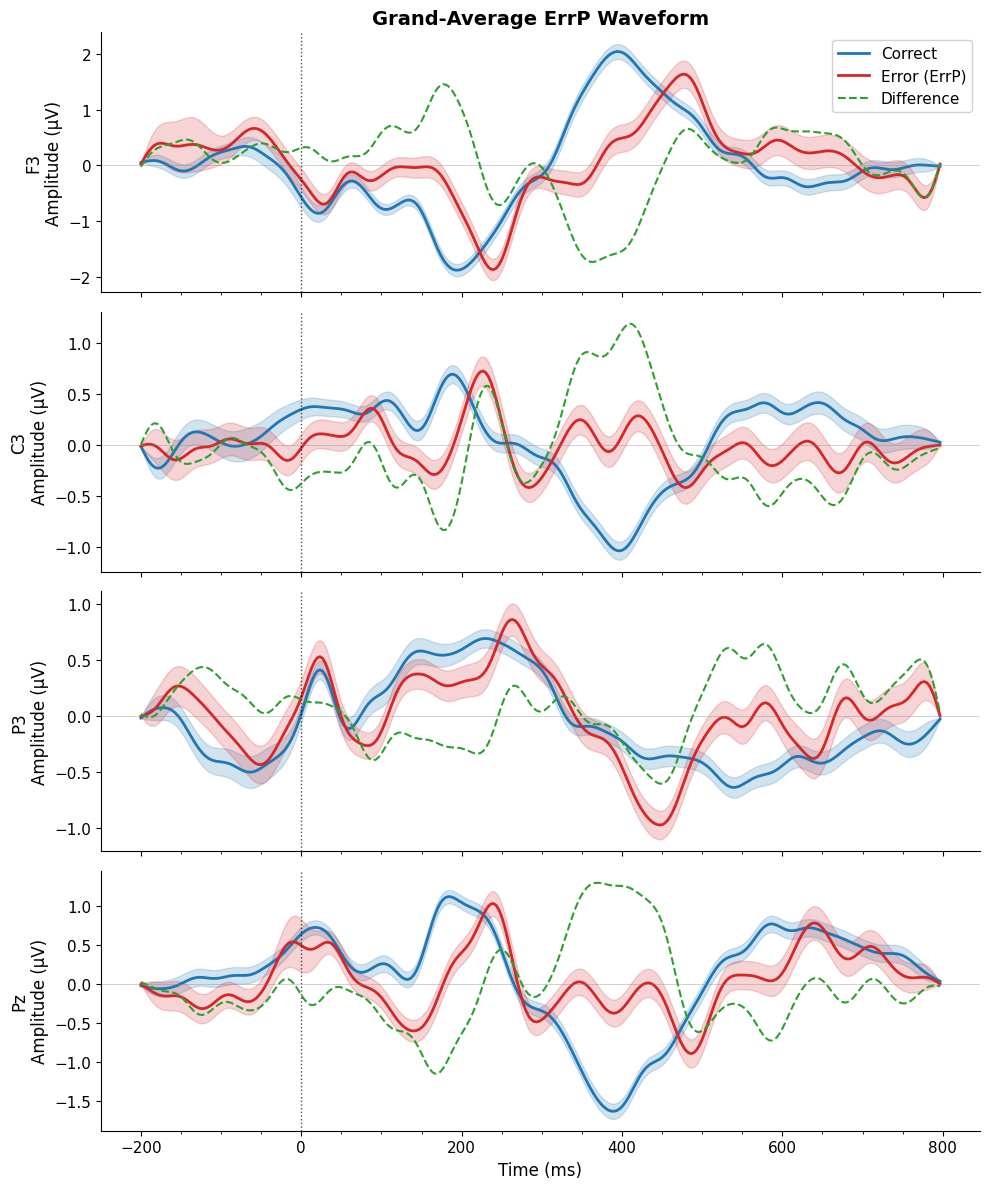


Figure saved to errp_grand_average.png


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# --- Settings ---
SFREQ = 300.0
CHANNELS = ['F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'Pz']
# Poster-friendly subset: midline-adjacent + Pz (most relevant for ErrP)
PLOT_CHANNELS = ['F3', 'C3', 'P3', 'Pz']  # edit to show different channels

n_samples, n_channels, n_times = cleaned_data.shape
times = np.linspace(-PRE_S, POST_S, n_times, endpoint=False) * 1000  # ms

# --- Separate conditions ---
errp_mask = (y == 1)
non_errp_mask = (y == 0)
errp_trials = cleaned_data[errp_mask]      # (N_err, C, T)
non_errp_trials = cleaned_data[non_errp_mask]  # (N_corr, C, T)

print(f'ErrP trials: {errp_trials.shape[0]}, Non-ErrP trials: {non_errp_trials.shape[0]}')

# --- Compute grand averages and SEM ---
errp_mean = errp_trials.mean(axis=0)       # (C, T)
non_errp_mean = non_errp_trials.mean(axis=0)
errp_sem = errp_trials.std(axis=0) / np.sqrt(errp_trials.shape[0])
non_errp_sem = non_errp_trials.std(axis=0) / np.sqrt(non_errp_trials.shape[0])

# --- Difference wave ---
diff_mean = errp_mean - non_errp_mean

# --- Plot ---
plot_idxs = [CHANNELS.index(ch) for ch in PLOT_CHANNELS]
n_plots = len(plot_idxs)

fig, axes = plt.subplots(n_plots, 1, figsize=(10, 3 * n_plots), sharex=True)
if n_plots == 1:
    axes = [axes]

colors = {'errp': '#d62728', 'non_errp': '#1f77b4', 'diff': '#2ca02c'}

for ax, ch_idx in zip(axes, plot_idxs):
    ch_name = CHANNELS[ch_idx]

    # Non-ErrP (correct)
    ax.plot(times, non_errp_mean[ch_idx] * 1e6, color=colors['non_errp'],
            linewidth=2, label='Correct')
    ax.fill_between(times,
                    (non_errp_mean[ch_idx] - non_errp_sem[ch_idx]) * 1e6,
                    (non_errp_mean[ch_idx] + non_errp_sem[ch_idx]) * 1e6,
                    color=colors['non_errp'], alpha=0.2)

    # ErrP (error)
    ax.plot(times, errp_mean[ch_idx] * 1e6, color=colors['errp'],
            linewidth=2, label='Error (ErrP)')
    ax.fill_between(times,
                    (errp_mean[ch_idx] - errp_sem[ch_idx]) * 1e6,
                    (errp_mean[ch_idx] + errp_sem[ch_idx]) * 1e6,
                    color=colors['errp'], alpha=0.2)

    # Difference wave
    ax.plot(times, diff_mean[ch_idx] * 1e6, color=colors['diff'],
            linewidth=1.5, linestyle='--', label='Difference')

    # Formatting
    ax.axvline(0, color='black', linestyle=':', linewidth=1, alpha=0.7)
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.set_ylabel(f'{ch_name}\nAmplitude (\u00b5V)', fontsize=12)
    ax.xaxis.set_minor_locator(MultipleLocator(50))
    ax.tick_params(labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].legend(fontsize=11, loc='upper right', framealpha=0.9)
axes[0].set_title('Grand-Average ErrP Waveform', fontsize=14, fontweight='bold')
axes[-1].set_xlabel('Time (ms)', fontsize=12)

plt.tight_layout()
plt.savefig('errp_grand_average.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nFigure saved to errp_grand_average.png')

please note that if you're on colab the paths in the below two cells do not need to be altered as they'll make colab clone our repository directly into your colab environment, from where you can access everything

In [27]:
import os
import subprocess
import sys
from pathlib import Path

def _is_colab_runtime() -> bool:
    return "google.colab" in sys.modules

def _repo_has_feature_module(root: Path) -> bool:
    return (root / "classify" / "feature.py").exists()

def _resolve_repo_root() -> Path:
    # 1) Honor explicit override first.
    env_root = os.environ.get("USER_REPO_ROOT")
    if env_root:
        p = Path(env_root).expanduser().resolve()
        if _repo_has_feature_module(p):
            return p

    # 2) Preferred defaults by runtime.
    if _is_colab_runtime():
        preferred = [
            Path("/content/ErrP"),
            Path("/content/drive/MyDrive/ErrP"),
            Path("/content/drive/MyDrive/Programming/ErrP"),
            Path("/content/drive/MyDrive/Colab Notebooks/ErrP"),
        ]
    else:
        preferred = [
            Path.cwd(),
            Path.cwd().parent,
            Path("/home/derick/Programming/ErrP"),
        ]

    for p in preferred:
        p = p.expanduser().resolve()
        if _repo_has_feature_module(p):
            return p

    # 3) If on Colab and repo missing, clone to /content/ErrP.
    if _is_colab_runtime():
        clone_target = Path("/content/ErrP")
        if not clone_target.exists():
            subprocess.run(
                ["git", "clone", "https://github.com/Neurotech-BCI/ErrP.git", str(clone_target)],
                check=True,
            )
            print(f"Cloned repo to {clone_target}")
        else:
            subprocess.run(["git", "-C", str(clone_target), "pull"], check=True)
            print(f"Repo already present at {clone_target}, pulled latest")
        return clone_target.resolve()

    raise FileNotFoundError(
        "Could not resolve ErrP repo root. Set USER_REPO_ROOT to your local ErrP path."
    )

REPO_ROOT = _resolve_repo_root()
os.environ["USER_REPO_ROOT"] = str(REPO_ROOT)
print(f"Using USER_REPO_ROOT={REPO_ROOT}")

Using USER_REPO_ROOT=/content/ErrP


In [28]:
import importlib
import importlib.util
import os
import sys
import types
from pathlib import Path
import numpy as np

# Optional env override (works for local VS Code and Colab).
USER_REPO_ROOT = os.environ.get("USER_REPO_ROOT")

def _repo_has_feature_module(root: Path) -> bool:
    return (root / "classify" / "feature.py").exists()

def _find_repo_root() -> Path:
    # 1) Explicit overrides first.
    explicit_candidates = [
        USER_REPO_ROOT,
        os.environ.get("REPO_ROOT"),
    ]
    for candidate in explicit_candidates:
        if not candidate:
            continue
        p = Path(candidate).expanduser().resolve()
        if _repo_has_feature_module(p):
            return p
        raise FileNotFoundError(
            f"Configured repo root does not contain classify/feature.py: {p}"
        )

    # 2) Fast direct checks for common locations.
    direct_candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path("/home/derick/Programming/ErrP"),
        Path("/content/ErrP"),
        Path("/content/drive/MyDrive/ErrP"),
        Path("/content/drive/MyDrive/Programming/ErrP"),
        Path("/content/drive/MyDrive/Colab Notebooks/ErrP"),
    ]
    seen = set()
    for p in direct_candidates:
        rp = p.expanduser().resolve()
        if rp in seen:
            continue
        seen.add(rp)
        if _repo_has_feature_module(rp):
            return rp

    # 3) Recursive fallback in likely parent roots.
    search_roots = [
        Path.cwd(),
        Path("/content"),
        Path("/home/derick/Programming"),
        Path.home(),
    ]
    for root in search_roots:
        if not root.exists():
            continue
        for fp in root.rglob("classify/feature.py"):
            return fp.parent.parent.resolve()

    raise FileNotFoundError(
        "Could not find ErrP repo root containing classify/feature.py. "
        "Set USER_REPO_ROOT to your ErrP folder path before running this cell."
    )

def _import_local_feature_wrapper(repo_root: Path):
    """Load classify.feature without executing classify/__init__.py."""
    repo_root = repo_root.resolve()
    pkg_dir = repo_root / "classify"
    feature_path = pkg_dir / "feature.py"
    if not feature_path.exists():
        raise FileNotFoundError(f"Missing feature module at: {feature_path}")

    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))

    # Remove stale classify modules that point to another checkout.
    stale_pkg = sys.modules.get("classify")
    stale_file = getattr(stale_pkg, "__file__", "") if stale_pkg else ""
    stale_path = getattr(stale_pkg, "__path__", []) if stale_pkg else []
    path_mismatch = stale_path and str(pkg_dir) not in [str(Path(p).resolve()) for p in stale_path]
    file_mismatch = stale_file and str(pkg_dir) not in str(stale_file)
    if stale_pkg and (file_mismatch or path_mismatch):
        for name in list(sys.modules):
            if name == "classify" or name.startswith("classify."):
                sys.modules.pop(name, None)

    # Create a lightweight package shell so relative imports in feature.py work.
    if "classify" not in sys.modules:
        pkg = types.ModuleType("classify")
        pkg.__path__ = [str(pkg_dir)]
        pkg.__package__ = "classify"
        sys.modules["classify"] = pkg

    module_name = "classify.feature"
    existing = sys.modules.get(module_name)
    if existing is not None:
        loaded_from = str(Path(getattr(existing, "__file__", "")).resolve()) if getattr(existing, "__file__", None) else ""
        if loaded_from != str(feature_path.resolve()):
            sys.modules.pop(module_name, None)

    if module_name not in sys.modules:
        spec = importlib.util.spec_from_file_location(module_name, str(feature_path))
        if spec is None or spec.loader is None:
            raise ImportError(f"Could not create import spec for {feature_path}")
        feature_mod = importlib.util.module_from_spec(spec)
        sys.modules[module_name] = feature_mod
        spec.loader.exec_module(feature_mod)
    else:
        feature_mod = sys.modules[module_name]

    return feature_mod.FeatureWrapper

REPO_ROOT = _find_repo_root()
FeatureWrapper = _import_local_feature_wrapper(REPO_ROOT)
wrapper = FeatureWrapper()
print(f"Using local repo root: {REPO_ROOT}")

desired_features = [
    "median_frequency",
    "power_bandwidth",
    "alpha_bandpower",
    "beta_bandpower",
    "theta_bandpower",
    "delta_bandpower",
    "fft_max_value",
    "rms",
    "std",
    "time_max_peak",
    "time_min_peak",
    "max_peak_value",
    "min_peak_value",
    "prominence",
    "mean_frequency",
    "snr1",
    "snr",
    "sinad",
    "peak_location",
    "wavelet_energy_2_4",
    "wavelet_energy_4_8",
]

print(
    "Shape of EEG data before computing features "
    "(number_of_samples, number_of_channels, number_of_timesteps):\n"
    f"{cleaned_data.shape}"
)
print()
features = np.stack(
    [wrapper.compute_features(sample, 300.0, desired_features=desired_features) for sample in cleaned_data]
)
print(
    "Shape of EEG data after computing features "
    "(number_of_samples, number_of_channels, number_of_features):\n"
    f"{features.shape}"
)

Using local repo root: /content/ErrP
Shape of EEG data before computing features (number_of_samples, number_of_channels, number_of_timesteps):
(7704, 7, 300)

Shape of EEG data after computing features (number_of_samples, number_of_channels, number_of_features):
(7704, 7, 21)


In [29]:
# Cell: pooled (leaky) + within-participant + across-participant (LOSO) + per-session
# Models:
#   * svc_thresh  - linear SVC (no class_weight), decision threshold tuned on an
#                   internal val split to maximize balanced accuracy.
#   * riemann     - pyriemann Covariances -> TangentSpace -> LogisticRegression
#                   on the 3D (trials, channels, time) epochs.
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score,
)
from sklearn.base import BaseEstimator, ClassifierMixin

try:
    from pyriemann.estimation import Covariances
    from pyriemann.tangentspace import TangentSpace
    _HAS_PYRIEMANN = True
except Exception as _e:
    print(f"[warn] pyriemann not available, skipping Riemannian model ({_e})")
    _HAS_PYRIEMANN = False

# ---- Resolve input sources ----
n_y = int(y.shape[0])

# flat features for SVC
if "features" in globals() and hasattr(features, "shape") and features.shape[0] == n_y:
    X_flat = features.reshape(features.shape[0], -1)
    flat_source = "features"
elif "cleaned_data" in globals() and hasattr(cleaned_data, "shape") and cleaned_data.shape[0] == n_y:
    X_flat = cleaned_data.reshape(cleaned_data.shape[0], -1)
    flat_source = "cleaned_data (fallback)"
elif "X" in globals() and hasattr(X, "shape") and X.shape[0] == n_y:
    X_flat = X.reshape(X.shape[0], -1)
    flat_source = "raw X (fallback)"
else:
    raise RuntimeError("No feature/source array matches y length. Re-run Cells 6, 7, and 9.")

# 3D epochs for pyriemann: prefer cleaned_data, fall back to raw X
X_epochs = None
epochs_source = None
if "cleaned_data" in globals() and hasattr(cleaned_data, "ndim") and cleaned_data.ndim == 3 and cleaned_data.shape[0] == n_y:
    X_epochs = cleaned_data.astype("float64")
    epochs_source = "cleaned_data"
elif "X" in globals() and hasattr(X, "ndim") and X.ndim == 3 and X.shape[0] == n_y:
    X_epochs = X.astype("float64")
    epochs_source = "raw X"

print(f"Flat source (svc_thresh): {flat_source} with {X_flat.shape[0]} samples, {X_flat.shape[1]} features")
if X_epochs is not None:
    print(f"Epoch source (riemann) : {epochs_source} with shape {X_epochs.shape}")
else:
    print("Epoch source (riemann) : unavailable -> riemann model skipped")

if "sample_participants" not in globals() or len(sample_participants) != n_y:
    sample_participants = np.array(["all"] * n_y)
else:
    sample_participants = np.asarray(sample_participants)

if "sample_sessions" not in globals() or len(sample_sessions) != n_y:
    sample_sessions = np.array([f"sample_{i}" for i in range(n_y)])
else:
    sample_sessions = np.asarray(sample_sessions)


# -----------------------------------------------------------------------------
# Threshold-tuned linear SVC
# -----------------------------------------------------------------------------
class ThresholdTunedSVC(BaseEstimator, ClassifierMixin):
    """Linear SVC + decision-threshold calibration.

    No class_weight. Uses an internal stratified train/val split to pick the
    decision-function threshold that maximizes balanced accuracy on the
    minority (positive = class 1) detection problem.
    """

    def __init__(self, C=1.0, val_size=0.2, random_state=42):
        self.C = C
        self.val_size = val_size
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        # Internal val split for threshold tuning
        strat = y if len(np.unique(y)) > 1 else None
        X_tr, X_val, y_tr, y_val = train_test_split(
            X, y, test_size=self.val_size, stratify=strat,
            random_state=self.random_state,
        )
        self.scaler_ = StandardScaler().fit(X_tr)
        self.svc_ = LinearSVC(C=self.C, dual="auto", max_iter=5000)
        self.svc_.fit(self.scaler_.transform(X_tr), y_tr)
        scores_val = self.svc_.decision_function(self.scaler_.transform(X_val))

        # sweep thresholds over unique val scores + endpoints
        unique_scores = np.unique(scores_val)
        if unique_scores.size > 200:
            qs = np.linspace(0, 1, 200)
            unique_scores = np.quantile(scores_val, qs)
        candidates = np.concatenate([
            [-np.inf], unique_scores, [np.inf],
        ])
        best_thr = 0.0
        best_bal = -np.inf
        for thr in candidates:
            preds = (scores_val > thr).astype(int)
            if len(np.unique(preds)) < 2 and thr not in (-np.inf, np.inf):
                continue
            bal = balanced_accuracy_score(y_val, preds)
            if bal > best_bal:
                best_bal = bal
                best_thr = thr
        self.threshold_ = float(best_thr)
        # Refit on full training set with the same scaler
        self.scaler_ = StandardScaler().fit(X)
        self.svc_ = LinearSVC(C=self.C, dual="auto", max_iter=5000)
        self.svc_.fit(self.scaler_.transform(X), y)
        self.classes_ = self.svc_.classes_
        return self

    def decision_function(self, X):
        return self.svc_.decision_function(self.scaler_.transform(np.asarray(X)))

    def predict(self, X):
        scores = self.decision_function(X)
        return (scores > self.threshold_).astype(int)


def _make_svc_thresh():
    return ThresholdTunedSVC(C=1.0, val_size=0.2, random_state=42)


def _make_riemann():
    return Pipeline([
        ("cov", Covariances(estimator="oas")),
        ("ts", TangentSpace()),
        ("logreg", LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced")),
    ])


MODELS = {"svc_thresh": (_make_svc_thresh, "flat")}
if _HAS_PYRIEMANN and X_epochs is not None:
    MODELS["riemann"] = (_make_riemann, "epochs")


def _get_X_for(kind):
    return X_flat if kind == "flat" else X_epochs


def _metrics_from_preds(y_true, y_pred, n_samples, class_count, subset_name, model_name, status="ok", extra=None):
    out = {
        "model": model_name,
        "subset": subset_name,
        "status": status,
        "n_samples": int(n_samples),
        "class_0": int(class_count.get(0, 0)),
        "class_1": int(class_count.get(1, 0)),
        "mean_accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "mean_precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "mean_recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "mean_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "precision_class1": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "recall_class1": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
    }
    if extra:
        out.update(extra)
    return out


def _evaluate_subset(idx, subset_name, model_name, random_state=42):
    factory, kind = MODELS[model_name]
    X_src = _get_X_for(kind)
    X_sub = X_src[idx]
    y_sub = y[idx]

    unique, counts = np.unique(y_sub, return_counts=True)
    class_count = {int(k): int(v) for k, v in zip(unique, counts)}

    if len(unique) < 2:
        return {"model": model_name, "subset": subset_name, "status": "skipped_single_class",
                "n_samples": int(len(y_sub)),
                "class_0": class_count.get(0, 0), "class_1": class_count.get(1, 0)}

    min_class = int(np.min(counts))
    n_splits = min(5, min_class)
    if n_splits < 2:
        return {"model": model_name, "subset": subset_name, "status": "skipped_too_few_samples",
                "n_samples": int(len(y_sub)),
                "class_0": class_count.get(0, 0), "class_1": class_count.get(1, 0)}

    cv_splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    preds_all, truth_all, idx_all = [], [], []
    for train_idx, test_idx in cv_splitter.split(X_sub, y_sub):
        model = factory()
        model.fit(X_sub[train_idx], y_sub[train_idx])
        y_pred = model.predict(X_sub[test_idx])
        preds_all.extend(np.asarray(y_pred).tolist())
        truth_all.extend(y_sub[test_idx].tolist())
        idx_all.extend(test_idx.tolist())

    order = np.argsort(idx_all)
    preds_all = np.array(preds_all)[order]
    truth_all = np.array(truth_all)[order]
    out = _metrics_from_preds(truth_all, preds_all, len(y_sub), class_count, subset_name, model_name)
    out["predictions"] = list(zip(preds_all.tolist(), truth_all.tolist()))
    return out


def _evaluate_loso(groups, model_name, subset_name="across_participant_loso"):
    factory, kind = MODELS[model_name]
    X_src = _get_X_for(kind)
    unique, counts = np.unique(y, return_counts=True)
    class_count = {int(k): int(v) for k, v in zip(unique, counts)}
    if len(unique) < 2:
        return {"model": model_name, "subset": subset_name, "status": "skipped_single_class",
                "n_samples": int(len(y)),
                "class_0": class_count.get(0, 0), "class_1": class_count.get(1, 0)}

    logo = LeaveOneGroupOut()
    per_fold = []
    preds_all, truth_all = [], []
    for train_idx, test_idx in logo.split(X_src, y, groups=groups):
        held_out = groups[test_idx][0]
        model = factory()
        model.fit(X_src[train_idx], y[train_idx])
        y_pred = np.asarray(model.predict(X_src[test_idx]))
        y_true = y[test_idx]
        preds_all.extend(y_pred.tolist())
        truth_all.extend(y_true.tolist())
        per_fold.append({
            "held_out_subject": str(held_out),
            "n_test": int(len(test_idx)),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
            "precision_weighted": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
            "recall_weighted": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
            "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
            "precision_class1": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
            "recall_class1": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        })

    truth_all = np.array(truth_all); preds_all = np.array(preds_all)
    summary = _metrics_from_preds(truth_all, preds_all, len(y), class_count, subset_name, model_name)
    fold_accs = np.array([f["accuracy"] for f in per_fold])
    fold_bal = np.array([f["balanced_accuracy"] for f in per_fold])
    fold_prec = np.array([f["precision_weighted"] for f in per_fold])
    summary.update({
        "mean_fold_accuracy": float(fold_accs.mean()),
        "std_fold_accuracy": float(fold_accs.std()),
        "mean_fold_balanced_accuracy": float(fold_bal.mean()),
        "std_fold_balanced_accuracy": float(fold_bal.std()),
        "mean_fold_precision": float(fold_prec.mean()),
        "std_fold_precision": float(fold_prec.std()),
        "per_fold": per_fold,
    })
    return summary


all_metrics = {}

for model_name in MODELS:
    print(f"\n--- running model: {model_name} ---")

    # 1) Pooled (LEAKY across subjects)
    all_metrics[f"{model_name}::pooled_leaky"] = _evaluate_subset(
        np.arange(n_y), "pooled_leaky", model_name
    )

    # 2) Within-participant
    within_rows = []
    for pid in sorted(np.unique(sample_participants)):
        idx = np.where(sample_participants == pid)[0]
        key = f"{model_name}::participant::{pid}"
        all_metrics[key] = _evaluate_subset(idx, f"participant::{pid}", model_name)
        if all_metrics[key].get("status") == "ok":
            within_rows.append(all_metrics[key])

    if within_rows:
        all_metrics[f"{model_name}::within_participant_mean"] = {
            "model": model_name,
            "subset": "within_participant_mean",
            "status": "ok",
            "n_subjects": len(within_rows),
            "mean_accuracy": float(np.mean([m["mean_accuracy"] for m in within_rows])),
            "std_accuracy": float(np.std([m["mean_accuracy"] for m in within_rows])),
            "balanced_accuracy": float(np.mean([m["balanced_accuracy"] for m in within_rows])),
            "mean_precision": float(np.mean([m["mean_precision"] for m in within_rows])),
            "mean_recall": float(np.mean([m["mean_recall"] for m in within_rows])),
            "mean_f1": float(np.mean([m["mean_f1"] for m in within_rows])),
            "precision_class1": float(np.mean([m["precision_class1"] for m in within_rows])),
            "recall_class1": float(np.mean([m["recall_class1"] for m in within_rows])),
        }

    # 3) Across-participant LOSO
    if len(np.unique(sample_participants)) >= 2:
        all_metrics[f"{model_name}::across_participant_loso"] = _evaluate_loso(
            sample_participants, model_name, subset_name="across_participant_loso",
        )

# Backward compatibility for downstream cells (confusion matrix / per-class report).
metrics = all_metrics.get("svc_thresh::pooled_leaky", next(iter(all_metrics.values())))

rows = []
for key, m in all_metrics.items():
    rows.append({
        "model": m.get("model"),
        "subset_key": key,
        "status": m.get("status"),
        "n_samples": m.get("n_samples"),
        "class_0": m.get("class_0"),
        "class_1": m.get("class_1"),
        "accuracy": m.get("mean_accuracy"),
        "balanced_accuracy": m.get("balanced_accuracy"),
        "precision_weighted": m.get("mean_precision"),
        "recall_weighted": m.get("mean_recall"),
        "f1_weighted": m.get("mean_f1"),
        "precision_class1": m.get("precision_class1"),
        "recall_class1": m.get("recall_class1"),
    })

results_df = pd.DataFrame(rows).sort_values(["model", "status", "subset_key"]).reset_index(drop=True)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 20)
print("\nEvaluation summary:")
print(results_df.to_string(index=False))


def _print_model_headlines(model_name):
    print(f"\n================ {model_name.upper()} ================")
    loso_key = f"{model_name}::across_participant_loso"
    if loso_key in all_metrics and all_metrics[loso_key].get("status") == "ok":
        loso = all_metrics[loso_key]
        print(f"[LOSO] pooled accuracy          : {loso['mean_accuracy']:.4f}")
        print(f"[LOSO] pooled balanced accuracy : {loso['balanced_accuracy']:.4f}")
        print(f"[LOSO] pooled weighted precision: {loso['mean_precision']:.4f}")
        print(f"[LOSO] mean fold accuracy       : {loso['mean_fold_accuracy']:.4f} +/- {loso['std_fold_accuracy']:.4f}")
        print(f"[LOSO] mean fold balanced acc   : {loso['mean_fold_balanced_accuracy']:.4f} +/- {loso['std_fold_balanced_accuracy']:.4f}")
        print(f"[LOSO] mean fold precision      : {loso['mean_fold_precision']:.4f} +/- {loso['std_fold_precision']:.4f}")
        print(f"[LOSO] ErrP-class precision     : {loso['precision_class1']:.4f}")
        print(f"[LOSO] ErrP-class recall        : {loso['recall_class1']:.4f}")
        print("[LOSO] per-fold:")
        for f in loso["per_fold"]:
            print(
                f"    {f['held_out_subject']:>10}  n={f['n_test']:<5}  "
                f"acc={f['accuracy']:.3f}  bal={f['balanced_accuracy']:.3f}  "
                f"prec={f['precision_weighted']:.3f}  rec={f['recall_weighted']:.3f}  "
                f"f1={f['f1_weighted']:.3f}"
            )
    wp_key = f"{model_name}::within_participant_mean"
    if wp_key in all_metrics:
        wp = all_metrics[wp_key]
        print(f"[within] accuracy          : {wp['mean_accuracy']:.4f} +/- {wp['std_accuracy']:.4f}")
        print(f"[within] balanced accuracy : {wp['balanced_accuracy']:.4f}")
        print(f"[within] weighted precision: {wp['mean_precision']:.4f}")
        print(f"[within] weighted recall   : {wp['mean_recall']:.4f}")
        print(f"[within] weighted f1       : {wp['mean_f1']:.4f}")
        print(f"[within] ErrP-class prec   : {wp['precision_class1']:.4f}")
        print(f"[within] ErrP-class recall : {wp['recall_class1']:.4f}")


for mn in MODELS:
    _print_model_headlines(mn)

if metrics.get("status") == "ok":
    pooled_summary = {k: v for k, v in metrics.items() if k not in ("predictions", "subset")}
    print("\nPooled (leaky) metrics used by downstream cells:")
    print(pooled_summary)
else:
    print("\nPooled evaluation was skipped. Check class balance / sample counts.")


Flat source (svc_thresh): features with 7704 samples, 147 features
Epoch source (riemann) : cleaned_data with shape (7704, 7, 300)

--- running model: svc_thresh ---

--- running model: riemann ---

Evaluation summary:
     model                          subset_key status  n_samples  class_0  class_1  accuracy  balanced_accuracy  precision_weighted  recall_weighted  f1_weighted  precision_class1  recall_class1
   riemann    riemann::across_participant_loso     ok     7704.0   5778.0   1926.0  0.539071           0.554431            0.665968         0.539071     0.569736          0.290539       0.585151
   riemann        riemann::participant::andrew     ok     2209.0   1641.0    568.0  0.571752           0.563259            0.664474         0.571752     0.598263          0.310621       0.545775
   riemann        riemann::participant::churek     ok      572.0    414.0    158.0  0.536713           0.525362            0.619874         0.536713     0.560932          0.298113       0.500000
 

In [30]:
from collections import defaultdict
correct = defaultdict(int)
total = defaultdict(int)

for pred, real in metrics["predictions"]:
    total[real] += 1
    if pred == real:
        correct[real] += 1
accuracy_per_class = {cls: correct[cls] / total[cls] for cls in total}
for k, v in accuracy_per_class.items():
    print(f"Accuracy for Class {k}: {(v*100):.1f}%")
print(f"Balanced Accuracy: {(np.mean(list(accuracy_per_class.values()))*100):.1f}%")


Accuracy for Class 0: 62.6%
Accuracy for Class 1: 54.3%
Balanced Accuracy: 58.4%


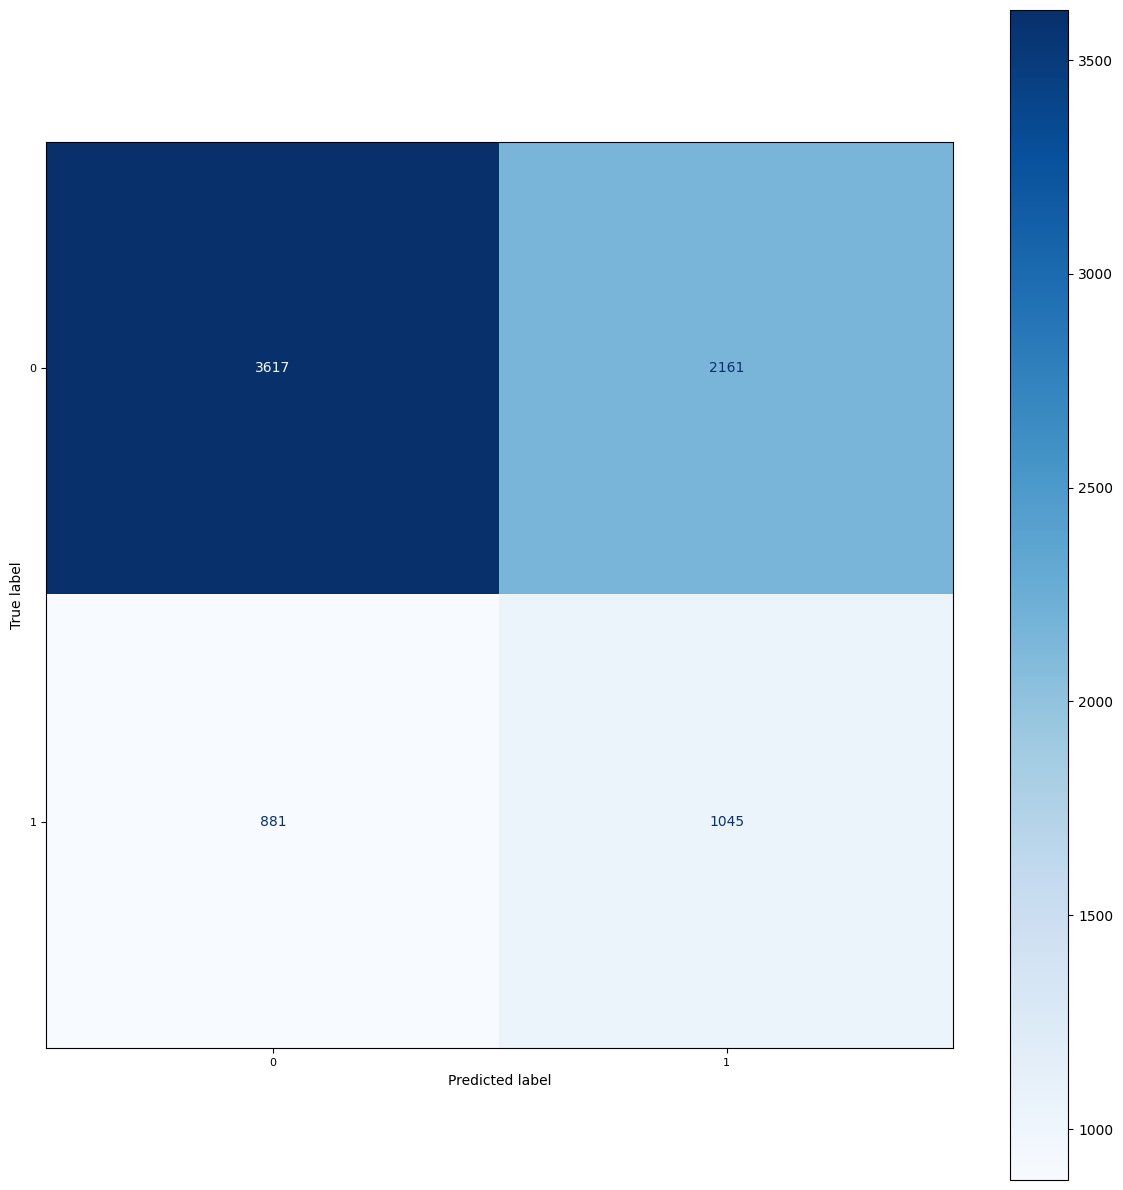

In [31]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds = [p for p, _ in metrics["predictions"]]
real = [p for _, p in metrics["predictions"]]

class_names = np.unique(real)
cm = confusion_matrix(real, preds, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap="Blues", colorbar=True)

plt.xticks(rotation=0, ha="center", fontsize=8)
plt.yticks(rotation=0, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

In [32]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report
import numpy as np

X_flat = features.reshape(features.shape[0], -1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "svm_rbf_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced")),
    ]),
    "svm_linear_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", C=1.0, class_weight="balanced")),
    ]),
    "logreg_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]),
    "rf_balanced": RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced_subsample",
        max_features="sqrt",
    ),
}

scores = {}
for name, model in candidates.items():
    y_pred = cross_val_predict(model, X_flat, y, cv=cv, n_jobs=-1)
    bacc = balanced_accuracy_score(y, y_pred)
    scores[name] = bacc
    print(f"{name}: balanced_accuracy={bacc:.4f}")

best_name = max(scores, key=scores.get)
print(f"\nBest candidate: {best_name} ({scores[best_name]:.4f})")

svm_rbf_balanced: balanced_accuracy=0.5601
svm_linear_balanced: balanced_accuracy=0.5902
logreg_balanced: balanced_accuracy=0.5831
rf_balanced: balanced_accuracy=0.5034

Best candidate: svm_linear_balanced (0.5902)
